# Lazy vs rich training dynamics

Left: `lazy_bs5_balance.json` (`init_block_scale = 5`). Right: `rich_bs1_balance.json` (`init_block_scale = 1`). Rows: real vs null frustration, loss, relative distance from the init.
The `distance` column in the json is the absolute L2 distance of the network edge weights, which scales with the init magnitude (the lazy run starts 5x larger, its OV product 25x); it is divided here by the init norm computed from the run's `train_config`, so the two panels share one y axis.
Formatted for a NeurIPS figure (5.5 in text width, Times, 8 pt). Writes `lazy_rich_balance.pdf` (use this in LaTeX) and `lazy_rich_balance.png` (preview).

The second figure repeats the pair with `weight_decay = 0` (`lazy_bs5wd0_balance.json` / `rich_bs1wd0_balance.json`, same init, same seed), written to `lazy_rich_balance_wd0.pdf` / `.png`.

The third figure is the Chizat-Bach pair (`lazy_alpha32_balance.json` / `rich_alpha1_balance.json`): same init in both (seed 0, GPT-2 residual rescale, `alpha_center = True`), the lazy run has `alpha = 32` on the logits with `learning_rate / 32` and `grad_clip = 32`. Written to `lazy_rich_balance_alpha.pdf` / `.png`.

Lazy (init scale $= 5$): ||theta_0|| = 1053.5, final relative distance = 0.805
Rich (init scale $= 1$): ||theta_0|| = 153.4, final relative distance = 1.664


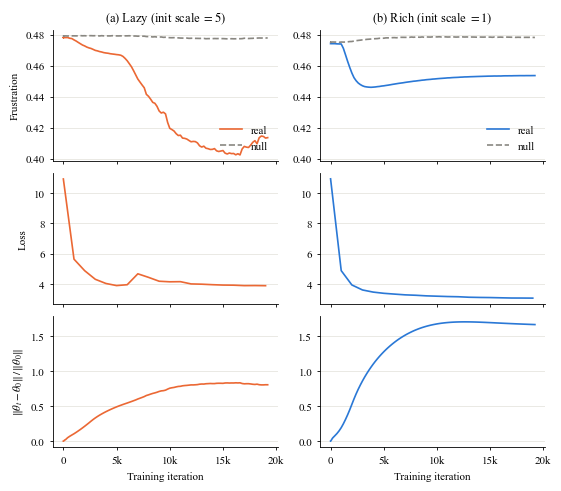

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# NeurIPS: 5.5 in text width, Times body font, embedded TrueType (no Type 3) fonts in the PDF.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "lines.linewidth": 1.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

LAZY_COLOR = "#eb6834"
RICH_COLOR = "#2a78d6"
NULL_COLOR = "#898781"


def init_edge_norm(tc):
    """||vals0||: L2 norm of the network edge weights at init (T=1, no embeddings), from the run config.

    The edges are W1, W2 and the product WO@WV of every block (transformer_utils.network_construction);
    the identity / attention edges are constants and cancel in the distance. Every weight is
    N(0, std^2) times init_block_scale, and c_proj (WO, W2) additionally times the residual scale,
    so E||W||^2 = numel * var. Matches the norm of the actual seed-0 init to 4 digits.
    init_block_scale is missing from configs written before it existed (the alpha runs): 1.0.
    """
    d, L, std, s = tc["n_embd"], tc["n_layer"], tc["init_std"], tc.get("init_block_scale", 1.0)
    proj = tc["init_proj_scale"] * (1 / np.sqrt(2 * L) if tc["init_scale_residual"] else 1.0)
    v_in = (std * s) ** 2           # variance of a W1 / WV entry
    v_out = (std * s * proj) ** 2   # variance of a W2 / WO entry
    per_layer = 4 * d * d * v_in + 4 * d * d * v_out + d * d * (d * v_in * v_out)  # W1 + W2 + WO@WV
    return np.sqrt(L * per_layer)


def plot_pair(runs, out):
    """runs: [(file, panel title, line colour), ...] -> 3 rows x len(runs) columns, saved as out.pdf / out.png"""
    fig, axes = plt.subplots(3, len(runs), figsize=(5.5, 4.8), sharex=True, constrained_layout=True)
    for col, (fname, title, color) in enumerate(runs):
        d = json.load(open(fname))
        tc = d["train_config"]
        it = np.array(d["epoch"])  # training iterations (max_iters = 19200)
        ax_frust, ax_loss, ax_dist = axes[:, col]

        ax_frust.plot(it, d["r_frust"], color=color, label="real")
        ax_frust.plot(it, [v[0] for v in d["n_frust"]], color=NULL_COLOR, ls="--", label="null")
        ax_frust.legend(loc="lower right", frameon=False)
        ax_frust.set_title(f"({'abcd'[col]}) {title}")

        # loss is only re-evaluated every eval_interval iterations; snapshots in between repeat the stale value
        evaluated = it % tc["eval_interval"] == 0
        ax_loss.plot(it[evaluated], np.array(d["loss"])[evaluated], color=color)

        # the json stores the absolute L2 distance ||theta_t - theta_0|| over the edge weights, which
        # scales with the init magnitude; divide by ||theta_0|| so the two runs are comparable
        norm0 = init_edge_norm(tc)
        rel = np.array(d["distance"], dtype=float) / norm0
        print(f"{title}: ||theta_0|| = {norm0:.1f}, final relative distance = {rel[-1]:.3f}")
        ax_dist.plot(it, rel, color=color)
        ax_dist.set_xlabel("Training iteration")
        ax_dist.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:g}k" if v else "0"))

    # same y scale across the runs in every row
    for row in axes:
        for ax in row[1:]:
            row[0].sharey(ax)
    axes[0, 0].set_ylabel("Frustration")
    axes[1, 0].set_ylabel("Loss")
    axes[2, 0].set_ylabel(r"$\|\theta_t - \theta_0\| \, / \, \|\theta_0\|$")
    for ax in axes.flat:
        ax.grid(axis="y", color="#e1e0d9", lw=0.5)

    fig.savefig(out.with_suffix(".pdf"))
    fig.savefig(out.with_suffix(".png"), dpi=300)


plot_pair([
    ("lazy_bs5_balance.json", r"Lazy (init scale $= 5$)", LAZY_COLOR),
    ("rich_bs1_balance.json", r"Rich (init scale $= 1$)", RICH_COLOR),
], Path("lazy_rich_balance"))


Lazy (init scale $= 5$, wd $= 0$): ||theta_0|| = 1053.5, final relative distance = 1.302
Rich (init scale $= 1$, wd $= 0$): ||theta_0|| = 153.4, final relative distance = 2.360


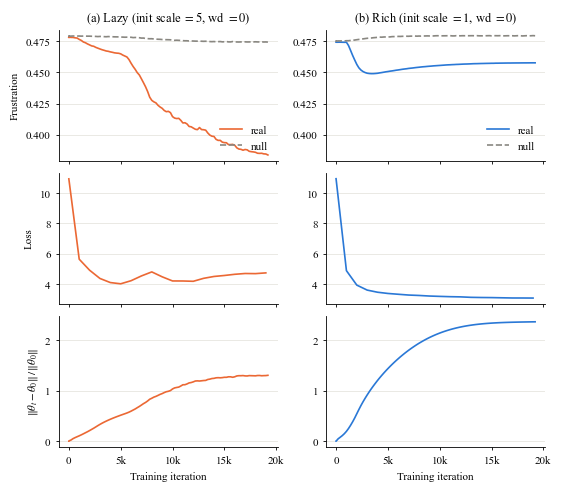

In [2]:
# same pair without weight decay (bs5_wd0 / bs1_wd0): the init is identical to the pair above,
# only AdamW's weight_decay on the matrices (wte/wpe, c_attn, c_proj, c_fc) goes from 0.1 to 0
plot_pair([
    ("lazy_bs5wd0_balance.json", r"Lazy (init scale $= 5$, wd $= 0$)", LAZY_COLOR),
    ("rich_bs1wd0_balance.json", r"Rich (init scale $= 1$, wd $= 0$)", RICH_COLOR),
], Path("lazy_rich_balance_wd0"))


Lazy ($\alpha = 32$): ||theta_0|| = 108.8, final relative distance = 0.047
Rich ($\alpha = 1$): ||theta_0|| = 108.8, final relative distance = 2.301


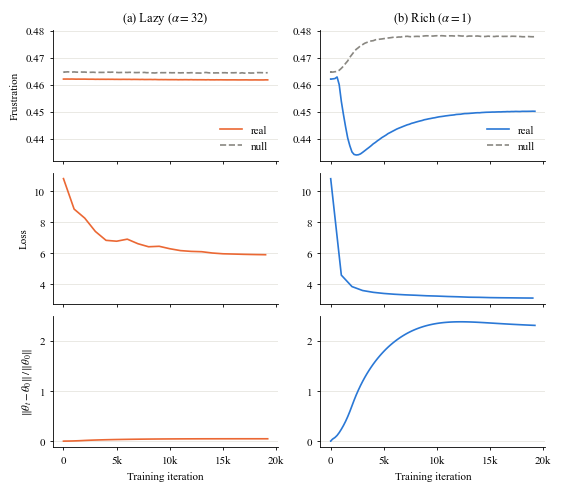

In [3]:
# Chizat-Bach output scaling (a32 / a1): identical init (seed 0, GPT-2 residual rescale on, no
# block scaling), alpha_center on in both. The lazy run multiplies the logits by alpha = 32 and
# divides learning_rate / min_lr by 32 (train.py), with grad_clip raised to 32 to match.
# alpha scales no weight, so ||theta_0|| is the same in both panels.
plot_pair([
    ("lazy_alpha32_balance.json", r"Lazy ($\alpha = 32$)", LAZY_COLOR),
    ("rich_alpha1_balance.json", r"Rich ($\alpha = 1$)", RICH_COLOR),
], Path("lazy_rich_balance_alpha"))
